# Customer Churn Analysis & Prevention Strategy
## Stage 1: Data Ingestion & Preprocessing

### Step 1: Load the data

In [301]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/customer-churn.csv')

print("\n---Before Type Conversion---")
print(f"Rows: {len(df)}")
print(df.dtypes)


---Before Type Conversion---
Rows: 7043
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Insight:** The dataset contains 7,043 customer records. A key data type issue is immediately apparent: the TotalCharges column was parsed as text (str) instead of a numeric type, which will prevent any financial calculations until it is fixed.

### Step 2: Clean the data

In [302]:
df.columns = df.columns.str.lower()
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

print(f"Number of missing values in totalcharges: {df['totalcharges'].isna().sum()}")
print(f"Tenure for these missing records: {df[df['totalcharges'].isna()]['tenure'].unique()}")

df['totalcharges'] = df['totalcharges'].fillna(0)

df['churn'] = df['churn'].replace({'Yes' : 1, 'No' : 0}).astype(int)

print('\n---After Data Cleaning & Transformation---')
print(f"Dataset shape: {df.shape}")
print(df.dtypes)

Number of missing values in totalcharges: 11
Tenure for these missing records: [0]

---After Data Cleaning & Transformation---
Dataset shape: (7043, 21)
customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object


**Insight:** Found 11 missing values in totalcharges. All correspond to new customers with tenure = 0. Since no billing occurred yet, these values were replaced with 0. The churn column was converted to 1 and 0.

### Step 3: Save to SQLite database

In [303]:
conn = sqlite3.connect("../data/churn_analysis.db")
df.to_sql('churn_analysis', conn, if_exists = 'replace', index = False)

print("\nDatabase created : churn_analysis.db")


Database created : churn_analysis.db


## Stage 2: Exploratory Data Overview

### Step 1: Basic Statistics

In [304]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges,churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


**Insight:** Average tenure is 32 months, but the median is lower - meaning most customers are relatively new. Monthly charges range widely (18-119 USD), suggesting a broad product mix.

### Step 2: Distribution of Key Numeric Features

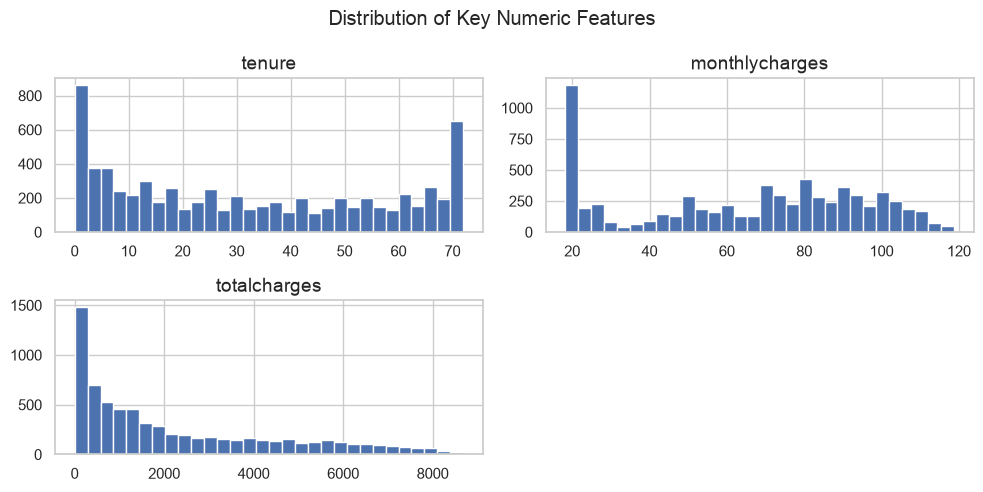

In [305]:
df[['tenure', 'monthlycharges', 'totalcharges']].hist(bins = 30, figsize = (10,5))
plt.suptitle('Distribution of Key Numeric Features')
plt.tight_layout()
plt.show()

**Insight:** Tenure distribution is roughly bimodal - a large group of very new customers and a large group of long-term ones, with fewer in the middle. Monthly charges skew toward higher values, reflecting the dominance of Fiber Optic plans.

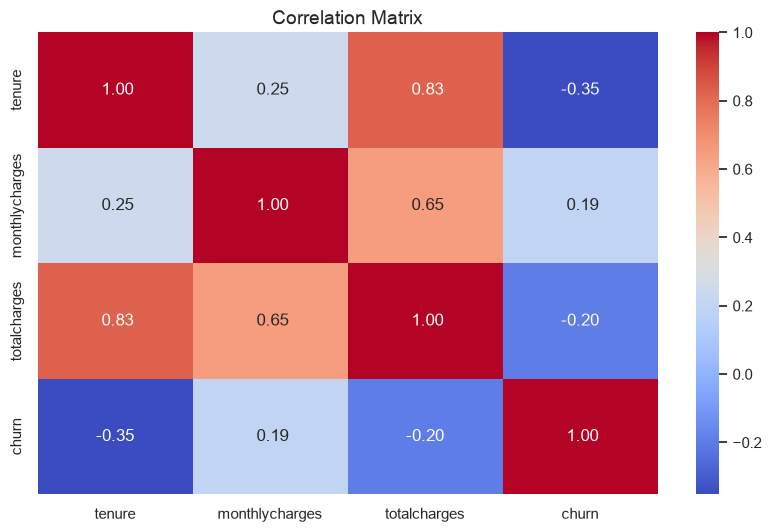

In [306]:
numeric_cols = df[['tenure', 'monthlycharges', 'totalcharges', 'churn']]
sns.heatmap(numeric_cols.corr(), annot = True, fmt = ' .2f', cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Insight:** Tenure has the strongest negative correlation with churn (-0.35) - the longer a customer stays, the less likely they are leave. Monthly charges show a slight positive correlation (0.19), suggesting higher-paying customers are marginally more likely to churn.

## Stage 3: Data Quality Validation

### DQ Check 1: Duplicates

In [307]:
query_duplicates = """
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT customerid) AS unique_customers
    FROM churn_analysis
    """
df_duplicates = pd.read_sql_query(query_duplicates, conn)
df_duplicates

,total_rows,unique_customers
0,7043,7043


**Insight:** Total row count matches the number of unique customer IDs (7,043). There are no duplicate records in the dataset.

### DQ Check 2: Missing Values in Totalcharges

In [308]:
query_nulls = """
    SELECT
        customerid, tenure, monthlycharges, totalcharges
    FROM churn_analysis
    WHERE totalcharges IS NULL
    """
df_nulls = pd.read_sql_query(query_nulls, conn)
df_nulls

,customerid,tenure,monthlycharges,totalcharges


### DQ Check 3: Business Logic Consistency Check

In [309]:
query_anomalies = """
    SELECT
        COUNT(*) AS anomaly_count
    FROM churn_analysis
    WHERE tenure = 0 AND totalcharges > 0
    """
df_anomalies = pd.read_sql_query(query_anomalies, conn)
df_anomalies

,anomaly_count
0,0


## Stage 4: Exploratory Data Analysis (EDA) & Base Churn Metrics


### EDA 1: Global Churn Rate

In [310]:
query_global_churn = """
    SELECT
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    """
df_global_churn = pd.read_sql_query(query_global_churn, conn)
df_global_churn

,total_customers,churned_customers,churned_percentage
0,7043,1869,26.54


**Insight:** 1 in 4 customers left. That's a high baseline and suggests a systemic issue, not a one-off problem.

### EDA 2: Churn by Contract Type

In [311]:
query_contract_churn = """
    SELECT
        contract,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    GROUP BY contract
    """
df_contract_churn = pd.read_sql_query(query_contract_churn, conn)
df_contract_churn

,contract,total_customers,churned_customers,churned_percentage
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [312]:
m2m = df_contract_churn.loc[df_contract_churn['contract'] == 'Month-to-month', 'churned_percentage'].values[0]
two_year = df_contract_churn.loc[df_contract_churn['contract'] == 'Two year', 'churned_percentage'].values[0]
ratio = round(m2m / two_year, 1)
print(f"Month-to-month churn is {ratio}x higher than two-year contracts ({m2m}% vs {two_year}%)")

Month-to-month churn is 15.1x higher than two-year contracts (42.71% vs 2.83%)


**Insight:** Month-to-month customers churn 15x more than two-year customers. No long-term commitment means any frustration leads to an immediate exit.


### EDA 3: Churn by Internet Service Type

In [313]:
query_internet_churn = """
    SELECT
        internetservice,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage,
        AVG(monthlycharges) AS avg_monthly_charges
    FROM churn_analysis
    GROUP BY internetservice
    ORDER BY churned_percentage DESC
    """
df_internet_churn = pd.read_sql_query(query_internet_churn, conn)
df_internet_churn

,internetservice,total_customers,churned_customers,churned_percentage,avg_monthly_charges
0,Fiber optic,3096,1297,41.89,91.500129
1,DSL,2421,459,18.96,58.102169
2,No,1526,113,7.40,21.079194


**Insight:** Fiber Optic customers pay the most but churn the most. The premium product has a retention problem.

### EDA 4: Churn Rate by Contract Type + Internet Service

In [314]:
query_cross_churn = """
    SELECT
        contract,
        internetservice,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate
    FROM churn_analysis
    GROUP BY contract, internetservice
    ORDER BY churn_rate DESC
    """
df_cross_churn = pd.read_sql_query(query_cross_churn, conn)
df_cross_churn

,contract,internetservice,total_customers,churned_customers,churn_rate
0,Month-to-month,Fiber optic,2128,1162,54.61
1,Month-to-month,DSL,1223,394,32.22
2,One year,Fiber optic,539,104,19.29
3,Month-to-month,No,524,99,18.89
4,One year,DSL,570,53,9.30
5,Two year,Fiber optic,429,31,7.23
6,One year,No,364,9,2.47
7,Two year,DSL,628,12,1.91
8,Two year,No,638,5,0.78


**Insight:** The highest-risk segment is Month-to-month Fiber Optic customers at 54.64% churn - more than half leave. Two-year Fiber Optic customers churn at just 7.23%, confirming that the Fiber product itself is not the problem: lack of long-term commitment is.

### EDA 5: Churn by Tech Support

In [315]:
query_support_churn = """
    SELECT
        techsupport,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
        FROM churn_analysis
        GROUP BY techsupport
        ORDER BY churned_percentage DESC
        """
df_support_churn = pd.read_sql_query(query_support_churn, conn)
df_support_churn

,techsupport,total_customers,churned_customers,churned_percentage
0,No,3473,1446,41.64
1,Yes,2044,310,15.17
2,No internet service,1526,113,7.40


In [316]:
no_support = df_support_churn.loc[df_support_churn['techsupport'] == 'No', 'churned_percentage'].values[0]
yes_support = df_support_churn.loc[df_support_churn['techsupport'] == 'Yes', 'churned_percentage'].values[0]
ratio = round(no_support / yes_support, 1)
print(f"No Tech Support churn is {ratio}x higher than with support ({no_support}% vs {yes_support}%)")

No Tech Support churn is 2.7x higher than with support (41.64% vs 15.17%)


**Insight:** Customers without Tech Support churn 2.7x more. Support isn't just a feature - it keeps people from leaving.

### Eda 6: Churn by Payment Method

In [317]:
query_payment_churn = """
    SELECT
        paperlessbilling,
        paymentmethod,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    GROUP BY paperlessbilling, paymentmethod
    ORDER BY churned_percentage DESC"""
df_payment_churn = pd.read_sql_query(query_payment_churn, conn)
df_payment_churn

,paperlessbilling,paymentmethod,total_customers,churned_customers,churned_percentage
0,Yes,Electronic check,1742,867,49.77
1,No,Electronic check,623,204,32.74
2,Yes,Mailed check,656,179,27.29
3,Yes,Bank transfer (automatic),891,186,20.88
4,Yes,Credit card (automatic),882,168,19.05
5,No,Mailed check,956,129,13.49
6,No,Bank transfer (automatic),653,72,11.03
7,No,Credit card (automatic),640,64,10.00


**Insight:** Electronic check + paperless billing is the riskiest combination at 49.77% churn. Customers on auto-pay (credit card or bank transfer) churn at 10-11% - suggesting that payment friction and manual billing reminders contribute to dropout.

### EDA 7: Churn by Senior Citizen Status

In [318]:
query_senior_churn = """
    SELECT
        CASE
            WHEN seniorcitizen = 1 THEN 'Senior'
            ELSE 'Non-Senior'
        END AS customer_segment,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    GROUP BY seniorcitizen
    ORDER BY churned_percentage DESC"""
df_senior_churn = pd.read_sql_query(query_senior_churn, conn)
df_senior_churn

,customer_segment,total_customers,churned_customers,churned_percentage
0,Senior,1142,476,41.68
1,Non-Senior,5901,1393,23.61


**Insight:** Senior churn at 41.68% vs 23.61% for non-seniors. Possible reasons: product complexity or price sensitivity. Both are worth addressing.

## Stage 5: Financial Impact Analysis

### Financial Impact 1: Global Revenue Loss

In [319]:
query_financial_impact = """
    SELECT
        SUM(monthlycharges) AS lost_monthly_revenue,
        SUM(totalcharges) AS lost_total_revenue
    FROM churn_analysis
    WHERE churn = 1
    """
df_financial_impact = pd.read_sql_query(query_financial_impact, conn)
df_financial_impact

,lost_monthly_revenue,lost_total_revenue
0,139130.85,2862926.9


**Insight:** Lost customers account for 139,130.85 USD in lost Monthly Recurring Revenue (MRR) and 2.86 million USD in total historical revenue loss.

### Financial Impact 2: Fiber Optic segment

In [320]:
query_fiber_loss = """
    SELECT
        SUM(monthlycharges) AS lost_monthly_revenue,
        SUM(totalcharges) AS lost_total_revenue
    FROM churn_analysis
    WHERE churn = 1 AND internetservice = 'Fiber optic'
    """
df_fiber_loss = pd.read_sql_query(query_fiber_loss, conn)
df_fiber_loss

,lost_monthly_revenue,lost_total_revenue
0,114300.05,2483257.45


**Insight:** The Fiber Optic segment causes the largest financial loss. It accounts for 114,300.05 USD in lost monthly revenue, which is over 82% of total monthly churn losses.

### Financial Impact 3: No Tech Support segment

In [321]:
query_support_loss = """
    SELECT
        SUM(monthlycharges) AS lost_monthly_revenue,
        SUM(totalcharges) AS lost_total_revenue
    FROM churn_analysis
    WHERE churn = 1 AND techsupport = 'No'
    """
df_support_loss = pd.read_sql_query(query_support_loss, conn)
df_support_loss

,lost_monthly_revenue,lost_total_revenue
0,110709.8,2023779.35


**Insight:** The lack of tech support accounts for 110,709.80 USD in lost monthly revenue. Expanding the technical support team is a justified investment.

### Financial Impact 4: The Critical Intersection (Fiber Optic + No Tech Support)

In [322]:
query_critical_leak = """
    SELECT
        SUM(monthlycharges) AS lost_monthly_revenue,
        SUM(totalcharges) AS lost_total_revenue
    FROM churn_analysis
    WHERE churn = 1 AND techsupport = 'No' AND internetservice = 'Fiber optic'
    """
df_critical_leak = pd.read_sql_query(query_critical_leak, conn)
df_critical_leak

,lost_monthly_revenue,lost_total_revenue
0,94900.8,1823201.25


**Insight:** This specific combination causes the highest financial loss, draining 94,900.80 USD in monthly recurring revenue and 1.82 million USD in historical losses. Fixing this issue will solve most of the revenue problem.

## Stage 6: Tenure and Cohort Analysis

### Tenure 1: Churn Rate by Exact Month

In [323]:
query_tenure_churn = """
    SELECT
        tenure,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    GROUP BY tenure
    ORDER BY churned_percentage DESC
    """
df_tenure_churn = pd.read_sql_query(query_tenure_churn, conn)
df_tenure_churn

,tenure,total_customers,churned_customers,churned_percentage
0,1,613,380,61.99
1,2,238,123,51.68
2,5,133,64,48.12
3,4,176,83,47.16
4,3,200,94,47.00
...,...,...,...,...
68,63,72,4,5.56
69,64,80,4,5.00
70,71,170,6,3.53
71,72,362,6,1.66


**Insight:** 61.99% of month-1 customers churn - the highest single-month dropout rate in the lifecycle. This is a churn *rate* per cohort, not a share of all churners. In reality, month-1 customers account for 20.33% of total churners, and the first 3 months combined - 31.94%. The pattern points to an onboarding failure: customers aren't finding value quickly enough.

### Tenure 2: Churn Distribution

In [324]:
query_churn_distribution = """
    SELECT
        CASE
            WHEN tenure <= 3  THEN '01-03 Months (Critical)'
            WHEN tenure <= 12 THEN '04-12 Months (First Year)'
            WHEN tenure <= 36 THEN '13-36 Months (Stable)'
            ELSE '36+ Months (Loyal)'
        END AS tenure_group,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / (SELECT SUM(churn) FROM churn_analysis), 2) AS pct_of_all_churners
    FROM churn_analysis
    GROUP BY tenure_group
    ORDER BY MIN(tenure)
    """
df_churn_distribution = pd.read_sql_query(query_churn_distribution, conn)
df_churn_distribution

,tenure_group,churned_customers,pct_of_all_churners
0,01-03 Months (Critical),597,31.94
1,04-12 Months (First Year),440,23.54
2,13-36 Months (Stable),474,25.36
3,36+ Months (Loyal),358,19.15


**Insight:** Churn is spread across the entire lifecycle - no single cohort dominates. The first 3 months contribute 31.94% of all churners, but the 13-36 month segment (25.36%) and first-year group (23.54%) are close behind. The retention problem is systemic, not limited to onboarding alone.

### Tenure 3: Cohort Buckets

In [325]:
query_tenure_buckets = """
    SELECT
        CASE
            WHEN tenure <= 3 THEN '1-3 months (Critical)'
            WHEN tenure <= 12 THEN '4-12 months (First Year)'
            WHEN tenure <= 36 THEN '13-36 months (Stable)'
            ELSE '36+ months (Loyal)'
        END AS tenure_group,
        COUNT(*) AS total_customers,
        SUM(churn) AS churned_customers,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churned_percentage
    FROM churn_analysis
    GROUP BY tenure_group
    ORDER BY MIN(tenure)
    """
df_tenure_buckets = pd.read_sql_query(query_tenure_buckets, conn)
df_tenure_buckets

,tenure_group,total_customers,churned_customers,churned_percentage
0,1-3 months (Critical),1062,597,56.21
1,4-12 months (First Year),1124,440,39.15
2,13-36 months (Stable),1856,474,25.54
3,36+ months (Loyal),3001,358,11.93


**Insight:** The first 3 months are critical, showing the highest churn rate at 56.21%. Once customers reach the loyal tier (36+ months), the churn rate drops to 11.93%.

### Tenure 4: Financial Leak by Cohort

In [326]:
query_leak_by_tenure = """
    SELECT
        CASE
            WHEN tenure <= 3 THEN '1-3 months (Critical)'
            WHEN tenure <= 12 THEN '4-12 months (First Year)'
            WHEN tenure <= 36 THEN '13-36 months (Stable)'
            ELSE '36+ months (Loyal)'
        END AS tenure_group,
        COUNT(*) AS total_customers,
        SUM(monthlycharges) AS lost_monthly_revenue,
        SUM(totalcharges) AS lost_total_revenue
    FROM churn_analysis
    WHERE churn = 1 AND techsupport = 'No' AND
    internetservice = 'Fiber optic'
    GROUP BY tenure_group
    ORDER BY MIN(tenure)
    """
df_leak_by_tenure = pd.read_sql_query(query_leak_by_tenure, conn)
df_leak_by_tenure

,tenure_group,total_customers,lost_monthly_revenue,lost_total_revenue
0,1-3 months (Critical),316,24960.20,38539.20
1,4-12 months (First Year),277,23625.25,176103.00
2,13-36 months (Stable),314,27767.30,633760.55
3,36+ months (Loyal),194,18548.05,974798.50


**Insight:** Revenue leak is roughly equal across all cohorts (~24K USD/month each) This is a systemic issue, not limited to one customer group.

## Stage 7: Presentation-Ready Data Visualizations

### Visualization Setup

In [327]:
sns.set_theme(style = "whitegrid")
PALETTE = 'deep'
plt.rcParams.update({
    'axes.titlesize' : 14,
    'axes.labelsize' : 12,
    'figure.figsize' : (10, 6),
})

### Chart 1: Churn Rate by Tenure Group

Saved: '01_churn_rate_by_tenure.png'


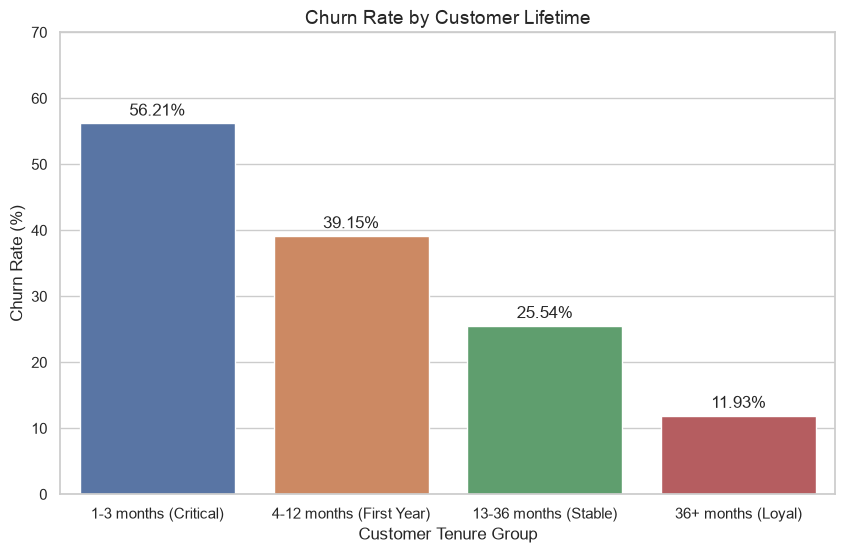

In [328]:
ax = sns.barplot(data = df_tenure_buckets, x = "tenure_group", y = "churned_percentage", hue = 'tenure_group', palette = PALETTE, legend = False)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.2f%%', padding = 3, fontsize = 12)
plt.title('Churn Rate by Customer Lifetime')
plt.xlabel('Customer Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 70)

plt.savefig('../visuals/01_churn_rate_by_tenure.png', dpi = 300, bbox_inches = 'tight')
print("Saved: '01_churn_rate_by_tenure.png'")


**Insight:** The chart highlights a high churn rate of 56.21% during the first 3 months. This confirms that retention efforts must focus heavily on onboarding new customers.

### Chart 2: Monthly Revenue Leak by Tenure Group

Saved: '02_monthly_leak_by_tenure.png'


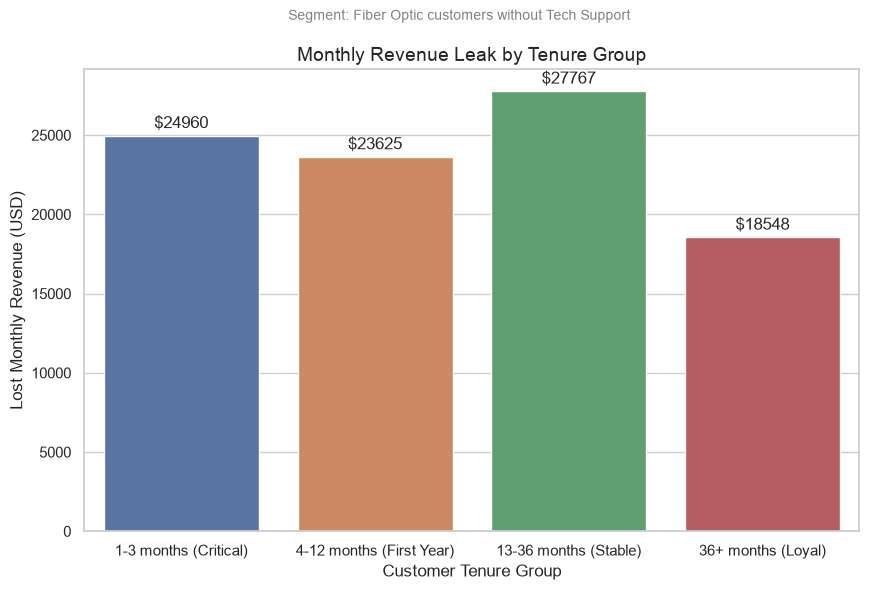

In [335]:
ax = sns.barplot(data = df_leak_by_tenure, x = 'tenure_group', y = 'lost_monthly_revenue', hue = 'tenure_group', palette = PALETTE, legend = False)
for container in ax.containers:
    ax.bar_label(container, fmt = '$%.0f', padding = 3, fontsize = 12)
plt.title('Monthly Revenue Leak by Tenure Group')
plt.xlabel('Customer Tenure Group')
plt.ylabel('Lost Monthly Revenue (USD)')

plt.suptitle('Segment: Fiber Optic customers without Tech Support', fontsize = 10, color = 'gray', y = 0.98)
plt.savefig('../visuals/02_monthly_leak_by_tenure.png', dpi = 300, bbox_inches = 'tight')
print("Saved: '02_monthly_leak_by_tenure.png'")

**Insight:** The monthly revenue leak is almost equal (around 24,000 USD/month) across all tenure groups. This shows that the issue affects both new and long-term customers equally.

### Chart 3: Month-by-month Churn Trend

Saved: '03_churn_trend_by_month.png'


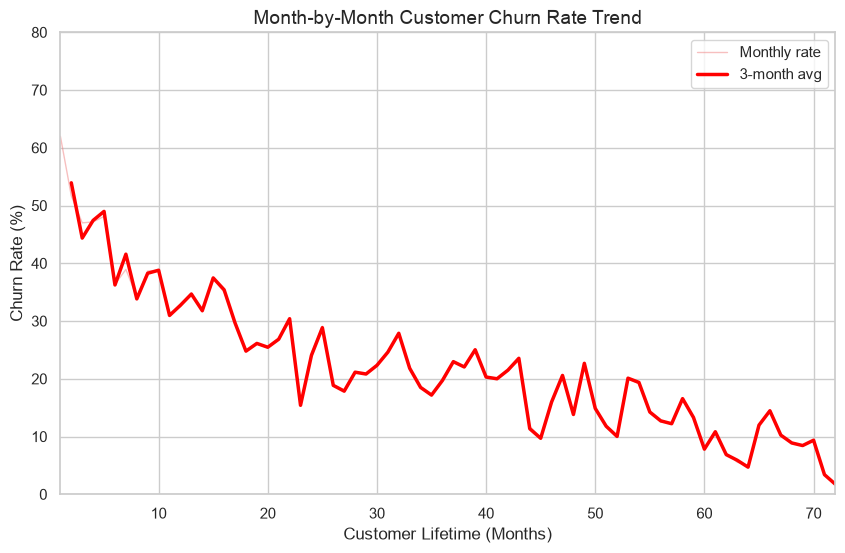

In [336]:
df_tenure_churn['churn_rate_smoothed'] = df_tenure_churn['churned_percentage'].rolling(window = 3, center = True).mean()
ax = sns.lineplot(data = df_tenure_churn, x = 'tenure', y = 'churned_percentage', color = 'lightcoral', linewidth = 1, alpha = 0.5, label = 'Monthly rate')
ax = sns.lineplot(data = df_tenure_churn, x = 'tenure', y = 'churn_rate_smoothed', color = 'red', linewidth = 2.5, label = '3-month avg')
plt.title("Month-by-Month Customer Churn Rate Trend")
plt.xlabel('Customer Lifetime (Months)')
plt.ylabel('Churn Rate (%)')
plt.xlim(1, 72)
plt.ylim(0, 80)

plt.savefig('../visuals/03_churn_trend_by_month.png', dpi = 300, bbox_inches = 'tight')
print("Saved: '03_churn_trend_by_month.png'")

**Insight:** The visualization shows a clear downward trend in attrition. The risk of customer churn is concentrated heavily within the first year of service.

### Chart 4: Churn Rate by Contract Type

Saved: '04_churn_by_contract.png'


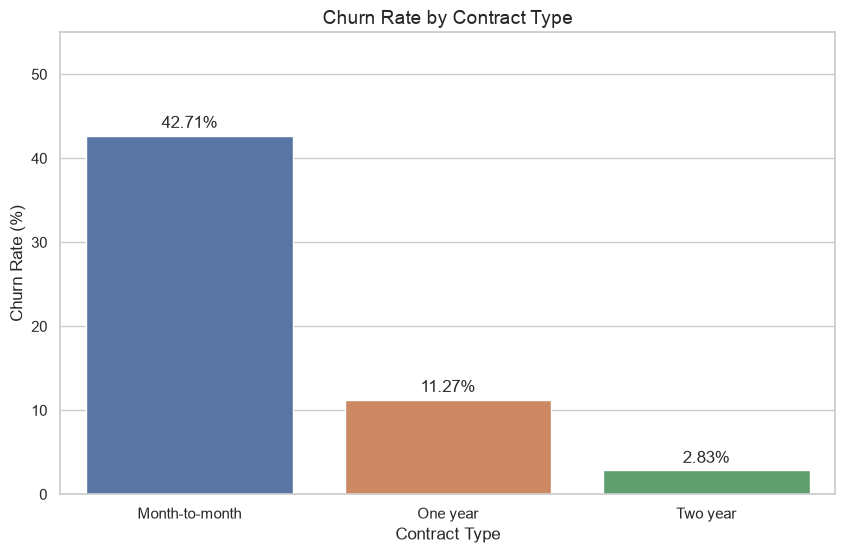

In [331]:
ax = sns.barplot(data = df_contract_churn, x = 'contract', y = 'churned_percentage', hue = 'contract', palette = PALETTE, legend = False)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.2f%%', padding = 3, fontsize = 12)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)

plt.savefig('../visuals/04_churn_by_contract.png', dpi = 300, bbox_inches = 'tight')
print("Saved: '04_churn_by_contract.png'")

**Insight:** Month-to-month contracts show a high churn rate of 42.71%, while two-year contracts drop to 2.83%. Providing financial incentives to shift users to annual plans is a clear solution.

### Chart 5: Senior Citizens vs Non-seniors

Saved: '05_churn_senior_vs_nonsenior.png'


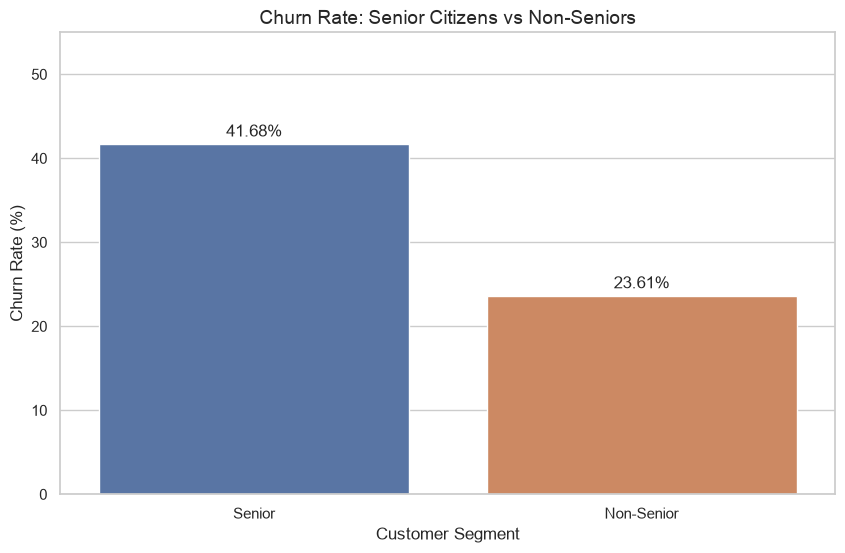

In [332]:
ax = sns.barplot(data = df_senior_churn, x = 'customer_segment', y = 'churned_percentage', hue = 'customer_segment', palette = PALETTE, legend = False)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.2f%%', padding = 3, fontsize = 12)
plt.title('Churn Rate: Senior Citizens vs Non-Seniors')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)

plt.savefig('../visuals/05_churn_senior_vs_nonsenior.png', dpi = 300, bbox_inches = 'tight')
print("Saved: '05_churn_senior_vs_nonsenior.png'")

**Insight:** Senior citizens show a high churn rate of 41.68% compared to non-seniors at 23.61%. This specific segment requires tailored retention offers.

In [333]:
conn.close()
print('Connection closed')

Connection closed


# Stage 8: Executive Summary & Business Recommendations

### Key Findings

1. **The 90-Day Critical Window:** Churn is concentrated in the earliest stages of the customer lifecycle. New customers in their first 3 months show a high 56.21% churn rate. Once customers reach the 36-month threshold, churn drops to 11.93%.
2. **The High-Risk Combination:** The intersection of Fiber Optic Internet Service and No Tech Support is the primary driver for early churn.
3. **Financial Impact:** This unsupported Fiber Optic segment represents the largest financial leak, draining 24,960.20 USD in monthly revenue from new customers (1-3 months) and an additional 23,625.25 USD from first-year clients (4-12 months).

---

### Strategic Recommendations for the Retention Team

* **Mandatory Technical Onboarding:** Automatically include 3 months of free Tech Support for every new customer signing up for Fiber Optic internet. This directly targets the 25k/month USD critical leak.
* **Proactive Engagement:** Deploy automated data-health checks and customer success outreach during days 30, 60, and 90 for high-risk cohorts.
* **Service Bundling Incentives:** Offer discounted long-term retention packages or support add-ons before the user enters their 4th month to ensure a stable transition into the first-year tier.